# Camada Física

Este documento demonstra o funcionamento da **Camada Física** da QuantumNet.  
A camada física é responsável por:
- Criação e gerenciamento de **qubits**
- Criação de **pares EPR** (pares entrelaçados)
- Medição de **fidelidade** de qubits e pares EPR
- Protocolos de criação de emaranhamento (**ECHP**)
- Simulação de **decoerência** ao longo do tempo via **Clock centralizado**

## 1. Imports e Configuração Inicial

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from quantumnet.components import Network, Host
from quantumnet.objects import Qubit, Logger
import random

## 2. Criando a Rede

Definimos uma topologia de **Grade 3x3**, que cria 9 hosts (nós 0 a 8) conectados em uma grade.  
Ao chamar `set_ready_topology`, a rede automaticamente:
1. Cria o grafo com a topologia escolhida
2. Inicializa os hosts com 10 qubits cada
3. Inicializa os canais com probabilidades aleatórias para on demand e replay
4. Distribui 10 pares EPR por canal

Hosts inicializados
Canais inicializados
Pares EPRs adicionados


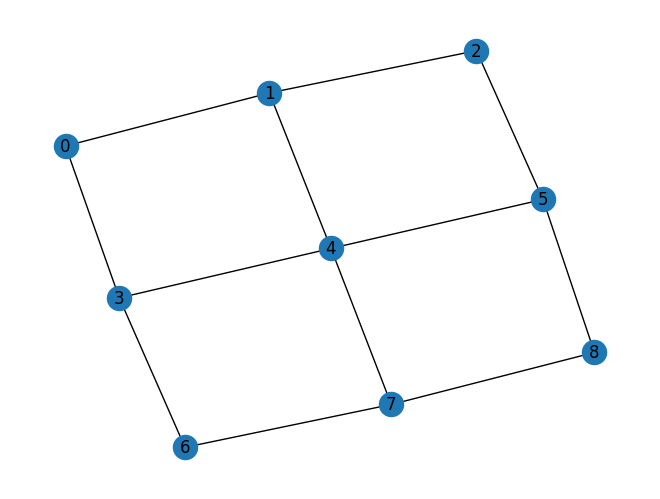

In [4]:
rede = Network()
rede.set_ready_topology('Grade', 3, 3)
rede.draw()

### Ativando o Logger

O Logger é um singleton. Ativamos para acompanhar as operações via console.

In [5]:
Logger.activate(Logger)

## 3. Selecionando Hosts (Alice e Bob)

Selecionamos aleatoriamente uma aresta do grafo da rede.  
Os dois hosts dessa aresta serão Alice e Bob.

In [6]:
arestas = list(rede.edges)
aresta_aleatoria = random.sample(arestas, 1)[0]
x, y = aresta_aleatoria

alice = rede.get_host(x)
bob = rede.get_host(y)

print(f'Alice: Host {alice.host_id}')
print(f'Bob: Host {bob.host_id}')

Alice: Host 5
Bob: Host 8


## 4. Manipulando Qubits

### 4.1 Adicionando qubits manualmente aos hosts

Além dos qubits criados automaticamente na inicialização, podemos criar e adicionar qubits manualmente. Cada `Qubit` recebe um ID e uma fidelidade inicial aleatória.

In [7]:
q1 = Qubit(1001)
q2 = Qubit(1002)

alice.add_qubit(q1)
bob.add_qubit(q2)

print(f'Qubit {q1.qubit_id} - Fidelidade inicial: {q1.get_initial_fidelity():.4f}')
print(f'Qubit {q2.qubit_id} - Fidelidade inicial: {q2.get_initial_fidelity():.4f}')

2026-02-22 15:09:28,478: Qubit 1001 adicionado à memória do Host 5.
2026-02-22 15:09:28,480: Qubit 1002 adicionado à memória do Host 8.


Qubit 1001 - Fidelidade inicial: 0.7099
Qubit 1002 - Fidelidade inicial: 0.5335


### 4.2 Acessando a memória dos hosts

Cada host possui uma memória (lista) de qubits.

In [8]:
print(f'Alice (Host {alice.host_id}) - Qubits na memória: {len(alice.memory)}')
print(f'Bob (Host {bob.host_id}) - Qubits na memória: {len(bob.memory)}')

Alice (Host 5) - Qubits na memória: 11
Bob (Host 8) - Qubits na memória: 11


### 4.3 Obtendo o último qubit de um host

`get_last_qubit()` retorna e **remove** o último qubit da memória do host (comportamento de pilha).

In [9]:
qubit_retirado = alice.get_last_qubit()
print(f'Qubit retirado: {qubit_retirado}')
print(f'Alice agora tem {len(alice.memory)} qubits na memória')

Qubit retirado: Qubit 1001 with state 0
Alice agora tem 10 qubits na memória


Vamos devolver o qubit para a Alice poder usar nos próximos protocolos.

In [10]:
alice.add_qubit(qubit_retirado)

2026-02-22 15:09:28,517: Qubit 1001 adicionado à memória do Host 5.


## 5. Medição de Fidelidade

A fidelidade mede a qualidade de um qubit. Quando o timeslot é > 0, a medição aplica um fator de decoerência de 0.99.

### 5.1 Fidelidade de um único qubit

In [11]:
fidelidade_q1 = rede.physical.fidelity_measurement_only_one(q1)
print(f'Fidelidade do Qubit {q1.qubit_id}: {fidelidade_q1:.6f}')

2026-02-22 15:09:28,531: A fidelidade do qubit Qubit 1001 with state 0 é 0.7098623230252259


Fidelidade do Qubit 1001: 0.709862


### 5.2 Fidelidade combinada entre dois qubits

A fidelidade combinada é o produto das fidelidades individuais.

In [12]:
fidelidade_combinada = rede.physical.fidelity_measurement(q1, q2)
print(f'Fidelidade combinada: {fidelidade_combinada:.6f}')

2026-02-22 15:09:28,543: A fidelidade do qubit Qubit 1001 with state 0 é 0.7098623230252259
2026-02-22 15:09:28,544: A fidelidade do qubit Qubit 1002 with state 0 é 0.5335298050567058
2026-02-22 15:09:28,545: A fidelidade entre o qubit 0.7098623230252259 e o qubit 0.5335298050567058 é 0.37873270682074905


Fidelidade combinada: 0.378733


## 6. Clock Centralizado e Decoerência

A rede utiliza um **Clock centralizado** que controla o avanço do tempo.  
- O tempo só avança quando `clock.tick()` é chamado (pelos protocolos ou manualmente)
- A cada tick, um callback de **decoerência** é disparado automaticamente:
  - Todos os qubits têm sua fidelidade multiplicada por **0.9**
  - Todos os pares EPR têm sua fidelidade multiplicada por **0.9**

Vamos verificar o timeslot atual e observar o histórico do clock.

In [13]:
print(f'Timeslot atual: {rede.clock.now}')
print(f'Eventos registrados no clock: {len(rede.clock.history)}')

Timeslot atual: 0
Eventos registrados no clock: 210


## 7. Protocolo de Criação de Emaranhamento (ECHP)

### 7.1 Entanglement Creation Heralding Protocol

O protocolo `entanglement_creation_heralding_protocol` cria um par EPR entre Alice e Bob.  
- Custo: **1 tick** (avança o clock, disparando decoerência)
- Consome o último qubit de cada host
- A fidelidade do EPR = fidelidade_qubit1 * fidelidade_qubit2
- Sucesso se fidelidade >= 0.8

In [14]:
print(f'Timeslot antes do ECHP: {rede.clock.now}')
resultado = rede.physical.entanglement_creation_heralding_protocol(alice, bob)
print(f'Timeslot após o ECHP: {rede.clock.now}')
print(f'Resultado do ECHP: {"Sucesso (fidelidade >= 0.8)" if resultado else "Fidelidade baixa (< 0.8)"}')

2026-02-22 15:09:28,582: Timeslot 1: Par epr criado com fidelidade 0.37873270682074905
2026-02-22 15:09:28,584: Timeslot 1: O protocolo de criação de emaranhamento foi bem sucedido, mas com fidelidade baixa.


Timeslot antes do ECHP: 0
Timeslot após o ECHP: 1
Resultado do ECHP: Fidelidade baixa (< 0.8)


### 7.2 Observando o efeito da decoerência

Após o tick do ECHP, a fidelidade dos qubits restantes foi degradada. Vamos verificar.

In [15]:
fidelidade_q1_apos = rede.physical.fidelity_measurement_only_one(q1)
print(f'Fidelidade do Qubit {q1.qubit_id} após 1 tick: {fidelidade_q1_apos:.6f}')
print(f'Note que a fidelidade diminuiu devido à decoerência automática.')

2026-02-22 15:09:28,599: A fidelidade do qubit Qubit 1001 with state 0 é 0.7027636997949737


Fidelidade do Qubit 1001 após 1 tick: 0.702764
Note que a fidelidade diminuiu devido à decoerência automática.


### 7.3 ECHP On Demand

O protocolo `echp_on_demand` tenta recriar emaranhamento entre dois hosts usando a probabilidade de sucesso **on demand** do canal.  
- Custo: **1 tick**
- Probabilidade de sucesso = `prob_on_demand_epr_create * fidelidade_q1 * fidelidade_q2`

Recebe os **IDs** dos hosts (não os objetos).

In [16]:
resultado_on_demand = rede.physical.echp_on_demand(alice.host_id, bob.host_id)
print(f'Resultado ECHP On Demand: {"Sucesso" if resultado_on_demand else "Falhou"}')
print(f'Timeslot atual: {rede.clock.now}')

2026-02-22 15:09:28,614: A fidelidade do qubit Qubit 59 with state 0 é 0.004182517167621559
2026-02-22 15:09:28,616: A fidelidade do qubit Qubit 89 with state 0 é 0.6760085110840997
2026-02-22 15:09:28,617: Timeslot 2: A probabilidade de sucesso do ECHP falhou.


Resultado ECHP On Demand: Falhou
Timeslot atual: 2


### 7.4 ECHP On Replay

O protocolo `echp_on_replay` é similar ao on demand, mas usa a probabilidade de **replay** do canal. É usado para recuperar emaranhamentos que estavam perdendo suas características.  
- Custo: **1 tick**
- Probabilidade de sucesso = `prob_replay_epr_create * fidelidade_q1 * fidelidade_q2`

In [17]:
resultado_on_replay = rede.physical.echp_on_replay(alice.host_id, bob.host_id)
print(f'Resultado ECHP On Replay: {"Sucesso" if resultado_on_replay else "Falhou"}')
print(f'Timeslot atual: {rede.clock.now}')

2026-02-22 15:09:28,634: A fidelidade do qubit Qubit 58 with state 0 é 0.4032153396055599
2026-02-22 15:09:28,634: A fidelidade do qubit Qubit 88 with state 0 é 0.6745967592956392
2026-02-22 15:09:28,635: Timeslot 3: A probabilidade de sucesso do ECHP falhou.


Resultado ECHP On Replay: Falhou
Timeslot atual: 3


## 8. Inspecionando Canais e EPRs

### 8.1 Propriedades de um canal

Cada aresta (canal) do grafo armazena:
- `prob_on_demand_epr_create`: probabilidade de criação on demand
- `prob_replay_epr_create`: probabilidade de criação on replay
- `eprs`: lista de pares EPR disponíveis no canal

In [18]:
canal = (alice.host_id, bob.host_id)
dados_canal = rede.graph.edges[canal]

print(f'Canal {canal}:')
print(f'  Probabilidade On Demand: {dados_canal["prob_on_demand_epr_create"]:.4f}')
print(f'  Probabilidade Replay:    {dados_canal["prob_replay_epr_create"]:.4f}')
print(f'  Número de EPRs no canal: {len(dados_canal["eprs"])}')

Canal (5, 8):
  Probabilidade On Demand: 0.2226
  Probabilidade Replay:    0.7115
  Número de EPRs no canal: 11


### 8.2 Todos os EPRs da rede

`get_eprs()` retorna um dicionário com todos os pares EPR alocados em cada canal.

In [19]:
todos_eprs = rede.get_eprs()
for aresta, eprs in todos_eprs.items():
    print(f'Canal {aresta}: {len(eprs)} EPRs')

Canal (0, 3): 10 EPRs
Canal (0, 1): 10 EPRs
Canal (1, 4): 10 EPRs
Canal (1, 2): 10 EPRs
Canal (2, 5): 10 EPRs
Canal (3, 6): 10 EPRs
Canal (3, 4): 10 EPRs
Canal (4, 7): 10 EPRs
Canal (4, 5): 10 EPRs
Canal (5, 8): 11 EPRs
Canal (6, 7): 10 EPRs
Canal (7, 8): 10 EPRs


## 9. Métricas de Uso

### 9.1 Qubits usados por camada

In [20]:
total_qubits = rede.get_total_useds_qubits()
print(f'Total de qubits usados: {total_qubits}')

2026-02-22 15:09:28,675: Qubits usados na camada PhysicalLayer: 6
2026-02-22 15:09:28,677: Qubits usados na camada LinkLayer: 0
2026-02-22 15:09:28,680: Qubits usados na camada TransportLayer: 0
2026-02-22 15:09:28,681: Qubits usados na camada ApplicationLayer: 0


Total de qubits usados: 6


### 9.2 EPRs usados por camada

In [21]:
total_eprs = rede.get_total_useds_eprs()
print(f'Total de EPRs usados: {total_eprs}')

2026-02-22 15:09:28,699: Eprs usados na camada PhysicalLayer: 1
2026-02-22 15:09:28,702: Eprs usados na camada LinkLayer: 0
2026-02-22 15:09:28,705: Eprs usados na camada NetworkLayer: 0


Total de EPRs usados: 1


## 10. Timeslots e Histórico

### 10.1 Timeslot atual

In [22]:
print(f'Timeslot atual (via clock): {rede.clock.now}')
print(f'Timeslot atual (via rede):  {rede.get_timeslot()}')

Timeslot atual (via clock): 3
Timeslot atual (via rede):  3


### 10.2 Histórico de eventos do Clock

O clock registra todos os eventos emitidos pelos protocolos. Cada evento contém o timeslot em que ocorreu e dados adicionais.

In [23]:
for evento in rede.clock.history:
    print(evento)

{'timeslot': 0, 'event': 'qubit_created', 'host_id': 0, 'qubit_id': 0}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 0, 'qubit_id': 1}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 0, 'qubit_id': 2}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 0, 'qubit_id': 3}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 0, 'qubit_id': 4}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 0, 'qubit_id': 5}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 0, 'qubit_id': 6}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 0, 'qubit_id': 7}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 0, 'qubit_id': 8}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 0, 'qubit_id': 9}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 1, 'qubit_id': 10}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 1, 'qubit_id': 11}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 1, 'qubit_id': 12}
{'timeslot': 0, 'event': 'qubit_created', 'host_id': 1, 'qubit_id': 13}
{'

### 10.3 Registro de criação de qubits

Podemos inspecionar em qual timeslot e camada cada qubit foi criado.

In [24]:
# Exibe os primeiros 10 registros para não poluir a saída
for qubit_id, info in list(rede.qubit_timeslots.items())[:10]:
    print(f'Qubit {qubit_id}: timeslot {info["timeslot"]}, camada {info["layer"]}')

Qubit 0: timeslot 0, camada Physical Layer
Qubit 1: timeslot 0, camada Physical Layer
Qubit 2: timeslot 0, camada Physical Layer
Qubit 3: timeslot 0, camada Physical Layer
Qubit 4: timeslot 0, camada Physical Layer
Qubit 5: timeslot 0, camada Physical Layer
Qubit 6: timeslot 0, camada Physical Layer
Qubit 7: timeslot 0, camada Physical Layer
Qubit 8: timeslot 0, camada Physical Layer
Qubit 9: timeslot 0, camada Physical Layer


## 11. Operações com Qubits

O objeto `Qubit` suporta portas quânticas básicas.

### 11.1 Porta X (NOT)

In [25]:
qubit_teste = Qubit(9999)
print(f'Estado inicial: {qubit_teste.measure()}')

qubit_teste.apply_x()
print(f'Após porta X: {qubit_teste.measure()}')

qubit_teste.apply_x()
print(f'Após segunda porta X: {qubit_teste.measure()}')

Estado inicial: 0
Após porta X: 1
Após segunda porta X: 0


### 11.2 Porta Hadamard

A porta Hadamard coloca o qubit em superposição. Na simulação, o resultado da medição é probabilístico (0 ou 1 com 50% de chance cada).

In [26]:
resultados = []
for _ in range(20):
    q = Qubit(0)
    q.apply_hadamard()
    resultados.append(q.measure())

print(f'Resultados de 20 medições após Hadamard: {resultados}')
print(f'Proporção de |0>: {resultados.count(0)/len(resultados):.2f}')
print(f'Proporção de |1>: {resultados.count(1)/len(resultados):.2f}')

Resultados de 20 medições após Hadamard: [1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1]
Proporção de |0>: 0.30
Proporção de |1>: 0.70
